In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:

# 1. Leitura dos dados 
df = pd.read_csv('../assets/raw_courses_data.csv', sep=',', low_memory=False)

# 2. Seleção das colunas com os múltiplos anos de salário
colunas_roi = [
    # Identificação base
    'UNITID','INSTNM', 'CIPCODE', 'CIPDESC', 'CREDLEV', 'IPEDSCOUNT1', 'DISTANCE',
    
    # Dívida Global e Desagregada
    'DEBT_ALL_STGP_ANY_MDN',
    'DEBT_MALE_STGP_ANY_MDN', 'DEBT_NOTMALE_STGP_ANY_MDN',
    'DEBT_PELL_STGP_ANY_MDN', 'DEBT_NOPELL_STGP_ANY_MDN',
    
    # ----------------------------------------------------
    # SALÁRIOS: GLOBAIS
    # ----------------------------------------------------
    'EARN_MDN_1YR', 'EARN_MDN_4YR', 'EARN_MDN_5YR',
    
    # ----------------------------------------------------
    # SALÁRIOS: ANO 1 (Género e Pell)
    # ----------------------------------------------------
    'EARN_MALE_WNE_MDN_1YR', 'EARN_NOMALE_WNE_MDN_1YR',
    'EARN_PELL_WNE_MDN_1YR', 'EARN_NOPELL_WNE_MDN_1YR',
    
    # ----------------------------------------------------
    # SALÁRIOS: ANO 3 (Género e Pell) 
    # ----------------------------------------------------
    'EARN_MALE_NE_MDN_3YR', 'EARN_NOMALE_NE_MDN_3YR',
    'EARN_PELL_NE_MDN_3YR', 'EARN_NOPELL_NE_MDN_3YR',
    
    # ----------------------------------------------------
    # SALÁRIOS: ANO 4 (Género e Pell)
    # ----------------------------------------------------
    'EARN_MALE_WNE_MDN_4YR', 'EARN_NOMALE_WNE_MDN_4YR',
    'EARN_PELL_WNE_MDN_4YR', 'EARN_NOPELL_WNE_MDN_4YR',

    # ----------------------------------------------------
    # SALÁRIOS: ANO 5 (Género e Pell)
    # ----------------------------------------------------
    'EARN_MALE_WNE_MDN_5YR', 'EARN_NOMALE_WNE_MDN_5YR',
    'EARN_PELL_WNE_MDN_5YR', 'EARN_NOPELL_WNE_MDN_5YR',
    
    # Sucesso a pagar a dívida (2 anos depois)
    'BBRR2_FED_COMP_MAKEPROG', 'BBRR2_FED_COMP_DFLT'
]

df_projeto = df[colunas_roi].copy()

# 3. Tratamento de valores ocultos (Privacy)
df_projeto.replace(['PrivacySuppressed', 'PS', 'NULL'], np.nan, inplace=True)
df_projeto.replace(r'^\s*$', np.nan, regex=True, inplace=True) # Limpa espaços em branco invisíveis

# 4. Conversão forçada para numérico em TODAS as colunas financeiras
colunas_para_converter = [
    'DEBT_ALL_STGP_ANY_MDN', 
    'EARN_MDN_1YR', 'EARN_MDN_4YR', 'EARN_MDN_5YR', 
    'IPEDSCOUNT1'
]

for col in colunas_para_converter:
    df_projeto[col] = pd.to_numeric(df_projeto[col], errors='coerce')

# 5. Trata valores inválidos

# A) A linha TEM de ter a informação da dívida geral
df_limpo = df_projeto.dropna(subset=['DEBT_ALL_STGP_ANY_MDN'])

# B) A linha TEM de ter TODOS os anos de salário globais (1, 4 e 5 anos)
df_limpo = df_limpo.dropna(subset=['EARN_MDN_1YR', 'EARN_MDN_4YR', 'EARN_MDN_5YR'], how='any')

# C) A linha TEM de ter TODOS os dados de Género ao longo do tempo (1, 3, 4 e 5 anos)
colunas_genero = [
    'EARN_MALE_WNE_MDN_1YR', 'EARN_NOMALE_WNE_MDN_1YR',
    'EARN_MALE_NE_MDN_3YR', 'EARN_NOMALE_NE_MDN_3YR',
    'EARN_MALE_WNE_MDN_4YR', 'EARN_NOMALE_WNE_MDN_4YR',
    'EARN_MALE_WNE_MDN_5YR', 'EARN_NOMALE_WNE_MDN_5YR'
]
df_limpo = df_limpo.dropna(subset=colunas_genero, how='any')

# D) A linha TEM de ter TODOS os dados de Bolsa Pell ao longo do tempo (1, 3, 4 e 5 anos)
colunas_pell = [
    'EARN_PELL_WNE_MDN_1YR', 'EARN_NOPELL_WNE_MDN_1YR',
    'EARN_PELL_NE_MDN_3YR', 'EARN_NOPELL_NE_MDN_3YR',
    'EARN_PELL_WNE_MDN_4YR', 'EARN_NOPELL_WNE_MDN_4YR',
    'EARN_PELL_WNE_MDN_5YR', 'EARN_NOPELL_WNE_MDN_5YR'
]
df_limpo = df_limpo.dropna(subset=colunas_pell, how='any')

# 6. Guardar os dados e extrair o código da família
df_limpo['CIP_FAMILIA'] = df_limpo['CIPCODE'].astype(str).str.replace(r'\.0', '', regex=True).str.zfill(4).str[:2]

df_limpo.to_csv("../data/clean_data.csv")
print(f"Nº final de linhas: {len(df_limpo)}")

Nº final de linhas: 5747


In [4]:
cols = ['UNITID', 'LATITUDE', 'LONGITUDE', 'STABBR', 'CITY', 'CONTROL']
df_geo = pd.read_csv('../assets/raw_institution_data.csv', usecols=cols)

# Usamos 'left' para garantir que não perdemos nenhum curso do teu dataset original
df_final = pd.merge(df_limpo, df_geo, on='UNITID', how='left')

# 4. Pequeno ajuste: O 'CONTROL' as vezes vem como número, vamos dar nome
# mapping_control = {1: 'Pública', 2: 'Privada (s/ fins)', 3: 'Privada (c/ fins)'}
# df_final['Tipo_Instituicao'] = df_final['CONTROL'].map(mapping_control)

# 5. Guardar o ficheiro
df_final.to_csv('../data/merged_data.csv', index=False)

print(f"Dataset pronto! Agora tens localização para {df_final['LATITUDE'].notna().sum()} linhas.")

NameError: name 'df_limpo' is not defined

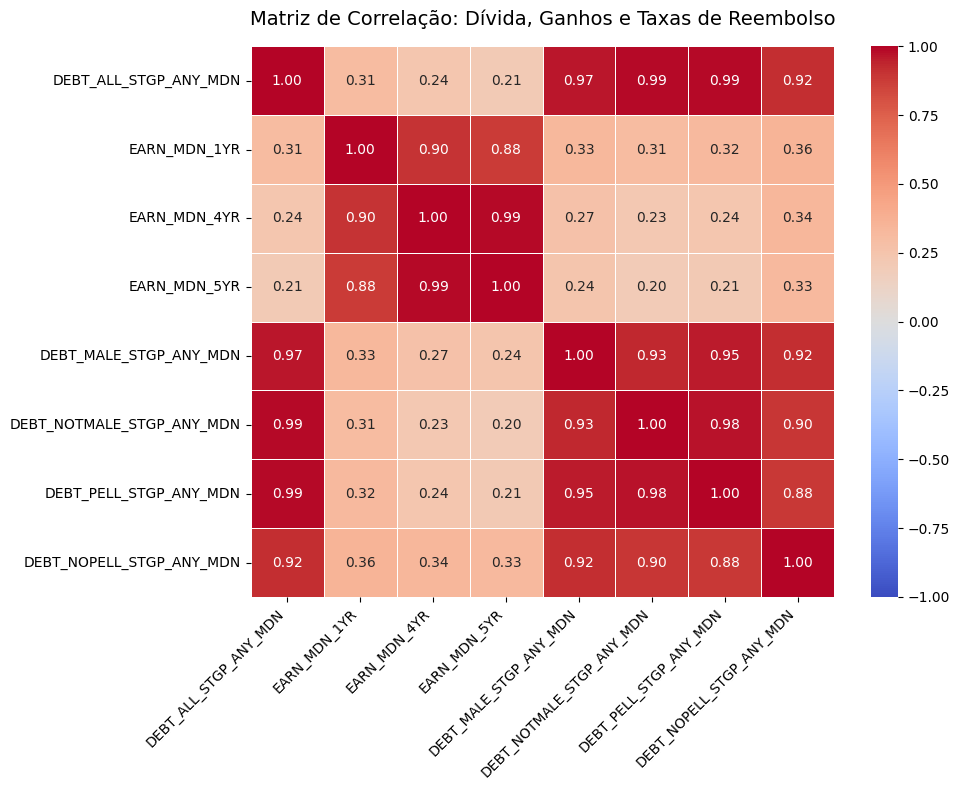

In [5]:
# 1. Carregar o teu dataset limpo
df_final = pd.read_csv('../data/merged_data.csv', sep=',')

# 2. Selecionar apenas as colunas numéricas (financeiras e contagens) para a correlação
colunas_numericas = [
    'DEBT_ALL_STGP_ANY_MDN', 
    'EARN_MDN_1YR', 
    'EARN_MDN_4YR', 
    'EARN_MDN_5YR',
    'DEBT_MALE_STGP_ANY_MDN', 
    'DEBT_NOTMALE_STGP_ANY_MDN',
    'DEBT_PELL_STGP_ANY_MDN', 
    'DEBT_NOPELL_STGP_ANY_MDN'
    #,'BBRR2_FED_COMP_MAKEPROG',
    #'BBRR2_FED_COMP_DFLT'
]

# Filtramos o dataset apenas para estas colunas
colunas_presentes = [col for col in colunas_numericas if col in df_final.columns]
df_corr = df_final[colunas_presentes]

# 3. Calcular a matriz de correlação (Método de Pearson)
matriz_correlacao = df_corr.corr()

# 4. Desenhar o Heatmap com o Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(
    matriz_correlacao, 
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5, 
    vmin=-1, vmax=1
)

plt.title('Matriz de Correlação: Dívida, Ganhos e Taxas de Reembolso', fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [18]:
import plotly.express as px

# 1. Preenchemos os NaNs na contagem de alunos com o valor 1
df_final['IPEDSCOUNT1'] = df_final['IPEDSCOUNT1'].fillna(1)

# 2. Desenhamos o gráfico novamente
fig = px.scatter(
    df_final,
    x='DEBT_ALL_STGP_ANY_MDN',
    y='EARN_MDN_4YR',
    size='IPEDSCOUNT1',
    color='CIP_FAMILIA',
    hover_name='INSTNM',
    title="ROI: Dívida vs. Salário a 4 Anos"
)

fig.show()